# Problem 1

In [14]:
import numpy as np 
import pandas as pd 

In [15]:
df = pd.read_csv('data.csv')
df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,Unknown,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69


In [16]:
# total missing values in each column
df.isnull().sum()

Age                       180
Income                    150
Salary                      0
Rating                     80
Annual_Income             120
Customer_Support_Calls     80
House_Price               100
Square_Feet                 0
Temperature                50
City                       50
Product_Type                0
Location                    0
Diagnosis                 220
Cabin                     680
Embarked                    2
Gender                      0
Target                      0
Price_Target                0
dtype: int64

In [19]:
# percentage of missing values in each column
print((df.isnull().sum()/len(df))*100)


Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64


In [20]:
print(df.loc[:, ((df.isnull().sum()/len(df))*100 > 50)])

       Cabin
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
..       ...
995      NaN
996  Cabin_D
997      NaN
998      NaN
999      NaN

[1000 rows x 1 columns]


# 03

In [21]:
df['Temperature'] = df['Temperature'].replace('Unknown', pd.NA)
df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
df['Temperature']

0      15.1
1      28.3
2      22.0
3      22.7
4       NaN
       ... 
995    17.0
996    17.0
997    24.7
998     NaN
999    14.1
Name: Temperature, Length: 1000, dtype: float64

# 04

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant', fill_value='Missing', add_indicator=True)
imputer.fit(df[['Diagnosis']])
df[['Diagnosis','indecator']] = imputer.transform(df[['Diagnosis']])
df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target,indecator
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,Missing,NaN,S,Male,0,280.32,True
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83,False
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43,False
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21,False
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92,False
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41,False
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89,False
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,NaN,Rajshahi,B,B,Missing,NaN,Q,Female,0,293.69,True


# 05

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Diagnosis', axis=1), df['Diagnosis'], random_state=42, test_size=0.2)
# for mean imputation
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train[['Age']])
X_train['Age_mean_imputed'] = imputer.transform(X_train[['Age']])

X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Cabin,Embarked,Gender,Target,Price_Target,indecator,Age_mean_imputed
29,NaN,20541.0,46632,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,B,B,NaN,S,Male,0,231.94,False,34.633888
535,35.0,46050.0,71684,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,B,B,NaN,Q,Female,0,228.30,True,35.000000
695,31.0,8652.0,85790,1.4,NaN,4.0,227513.0,1812,24.2,NaN,C,C,NaN,C,Male,0,266.84,True,31.000000
557,29.0,93707.0,52109,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,A,B,NaN,S,Female,0,221.75,True,29.000000
836,53.0,41021.0,61257,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,B,C,NaN,S,Female,0,261.28,True,53.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,A,A,NaN,S,Female,0,161.48,False,57.000000
270,52.0,55063.0,52856,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,B,A,NaN,C,Female,0,303.58,True,52.000000
860,37.0,7655.0,54442,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,Unknown,A,NaN,S,Female,0,327.19,False,37.000000
435,35.0,48894.0,50286,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,A,A,NaN,S,Male,0,311.50,False,35.000000


In [26]:
# for median imputation
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[['Age']])
X_train['Age_median_imputed'] = imputer.transform(X_train[['Age']])

X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Cabin,Embarked,Gender,Target,Price_Target,indecator,Age_mean_imputed,Age_median_imputed
29,NaN,20541.0,46632,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,B,B,NaN,S,Male,0,231.94,False,34.633888,34.0
535,35.0,46050.0,71684,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,B,B,NaN,Q,Female,0,228.30,True,35.000000,35.0
695,31.0,8652.0,85790,1.4,NaN,4.0,227513.0,1812,24.2,NaN,C,C,NaN,C,Male,0,266.84,True,31.000000,31.0
557,29.0,93707.0,52109,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,A,B,NaN,S,Female,0,221.75,True,29.000000,29.0
836,53.0,41021.0,61257,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,B,C,NaN,S,Female,0,261.28,True,53.000000,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,A,A,NaN,S,Female,0,161.48,False,57.000000,57.0
270,52.0,55063.0,52856,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,B,A,NaN,C,Female,0,303.58,True,52.000000,52.0
860,37.0,7655.0,54442,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,Unknown,A,NaN,S,Female,0,327.19,False,37.000000,37.0
435,35.0,48894.0,50286,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,A,A,NaN,S,Male,0,311.50,False,35.000000,35.0


<Axes: xlabel='Age_mean_imputed', ylabel='Density'>

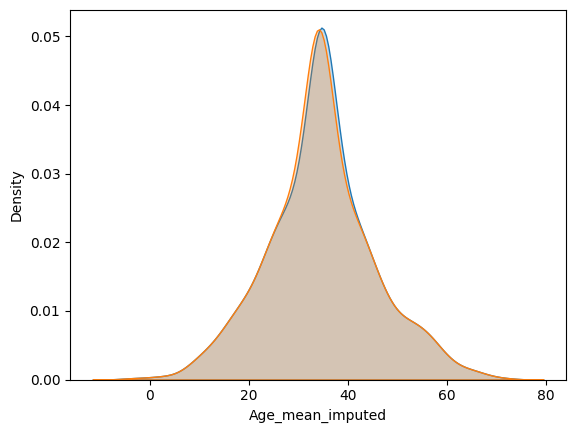

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
import seaborn as sns
sns.kdeplot(X_train['Age_mean_imputed'], label='Mean Imputed', fill=True)
sns.kdeplot(X_train['Age_median_imputed'], label='Median Imputed', fill=True)

```python
এখানে দুইটা KDE curve প্রায় overlap করেছে, অর্থাৎ mean এবং median imputation — দুটিই distribution খুব বেশি পরিবর্তন করেনি।

তবুও সাধারণভাবে আমি **Median Imputation** choose করতাম ✅

কারণ:

* median outlier-এর প্রভাবে কম affected হয়
* skewed data হলে median বেশি robust
* real-world datasets এ missing numerical data handle করতে median safer choice

যদি data perfectly normal distribution follow করে এবং outlier না থাকে, তখন mean imputationও ভালো কাজ করে।

এই plot দেখে মনে হচ্ছে:

* difference খুব কম
* তাই দুটোই acceptable
* কিন্তু robustness এর জন্য median slightly better choice।


# 06

```python

1. median - because skewed
2. mean - normal distribution
3. high frequency (mode) - categorical data
4. constant-Unknown imputation - as equal categories
5. drop column - as 68% null